# Freeviz classification results evaluation

In [1]:
from models import Freeviz
from utils import scale_features, load_zoo_data

import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# data preparation
E_raw, C, names, feature_names, class_names = load_zoo_data(device)
E = scale_features(E_raw)

10-fold cross classification with kNN classification on the zoological dataset

In [4]:
# hyperparams
n_folds = 10
k_nn = [1, 3, 5, 7, 9, 11]

rng = np.random.default_rng(42)

idx = rng.permutation(E.shape[0])
folds = np.array_split(idx, n_folds)

# n-fold cross classificattion with kNN with different k-s.
results = []
stds = []
for k in k_nn:
    accs = []
    print(n_folds, "cross evaluation on", "k:", k)
    for i in range(n_folds):
        
        # split data into train and test sets
        test_idx = torch.tensor(folds[i], dtype=torch.long, device=device)
        train_idx = torch.tensor(np.concatenate([f for j, f in enumerate(folds) if j != i]), dtype=torch.long, device=device)
        E_train, C_train = E[train_idx], C[train_idx]
        E_test, C_test = E[test_idx], C[test_idx]

        # train model
        freeviz = Freeviz(E.shape[1]).to(device)
        freeviz.train(E_train, C_train, print_loss=False)

        # evaluate model
        acc = freeviz.accuracy(E_train, C_train, E_test, C_test, k=k).item()
        accs.append(acc)
        print(f"fold {i + 1}/{n_folds}: acc={acc:.4f}")

    # organise results
    acc = np.array(accs).mean()
    std = np.array(accs).std(ddof=1)
    results.append(acc)
    stds.append(std)
    print(f"10-fold CV (k={k}) mean={acc:.4f} std={std:.4f}\n")

10 cross evaluation on k: 1
fold 1/10: acc=0.9091
fold 2/10: acc=0.9000
fold 3/10: acc=0.9000
fold 4/10: acc=0.8000
fold 5/10: acc=0.9000
fold 6/10: acc=1.0000
fold 7/10: acc=0.9000
fold 8/10: acc=0.9000
fold 9/10: acc=0.9000
fold 10/10: acc=0.9000
10-fold CV (k=1) mean=0.9009 std=0.0472

10 cross evaluation on k: 3
fold 1/10: acc=1.0000
fold 2/10: acc=0.8000
fold 3/10: acc=0.9000
fold 4/10: acc=0.8000
fold 5/10: acc=0.9000
fold 6/10: acc=1.0000
fold 7/10: acc=0.9000
fold 8/10: acc=0.9000
fold 9/10: acc=0.9000
fold 10/10: acc=0.9000
10-fold CV (k=3) mean=0.9000 std=0.0667

10 cross evaluation on k: 5
fold 1/10: acc=1.0000
fold 2/10: acc=0.5000
fold 3/10: acc=0.8000
fold 4/10: acc=0.8000
fold 5/10: acc=0.9000
fold 6/10: acc=1.0000
fold 7/10: acc=0.8000
fold 8/10: acc=0.8000
fold 9/10: acc=0.9000
fold 10/10: acc=0.9000
10-fold CV (k=5) mean=0.8400 std=0.1430

10 cross evaluation on k: 7
fold 1/10: acc=0.9091
fold 2/10: acc=0.5000
fold 3/10: acc=0.8000
fold 4/10: acc=0.9000
fold 5/10: acc

# Results visualization

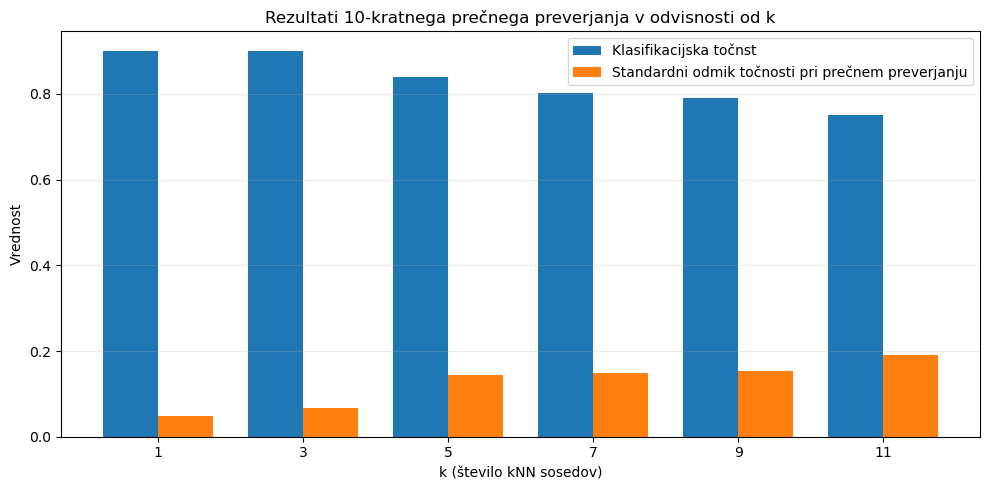

In [5]:
x = np.arange(len(k_nn))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - bar_width / 2, results, width=bar_width, label="Klasifikacijska točnst")
ax.bar(x + bar_width / 2, stds, width=bar_width, label="Standardni odmik točnosti pri prečnem preverjanju")

ax.set_xticks(x)
ax.set_xticklabels([str(k) for k in k_nn])
ax.set_xlabel("k (število kNN sosedov)")
ax.set_ylabel("Vrednost")
ax.set_title(f"Rezultati {n_folds}-kratnega prečnega preverjanja v odvisnosti od k")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("../final_vizualizations/freeviz_classification_eval.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/freeviz_classification_eval.png", format="png", bbox_inches="tight")
plt.show()